In [1]:
import itertools
import json
import os

import anndata as ad
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.spatial
import seaborn as sns
import sklearn
import torch
import tqdm
import umap

import celltrip

2026-02-02 23:14:24.650935: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
# Load data
adatas = celltrip.utility.processing.read_adatas(
    's3://nkalafut-celltrip/dyngen/logcounts.h5ad',
    's3://nkalafut-celltrip/dyngen/counts_protein.h5ad',
    backed=True)
modalities = ['Gene Expression', 'Protein Expression']

# Model list
prefixes = {
    'CellTRIP': 's3://nkalafut-celltrip/checkpoints/Dyngen-251015',
    'w/o Pinning': 's3://nkalafut-celltrip/checkpoints/Dyngen-260121-NoPinning',
    'w/o Velocity': 's3://nkalafut-celltrip/checkpoints/Dyngen-260121-NoVelocity',
    'w/o Action': 's3://nkalafut-celltrip/checkpoints/Dyngen-260121-NoAction',
    'w/o Action,Velocity': 's3://nkalafut-celltrip/checkpoints/Dyngen-260121-OnlyPinning',
}

# Load managers
managers = {
    k: celltrip.manager.BasicManager(
        adatas=adatas,
        policy_fname=f'{prefix}-{800:04}.weights',
        preprocessing_fname=f'{prefix}.pre',
        mask_fname=f'{prefix}.mask',
        device='cuda',
    )
    for k, prefix in prefixes.items()
}

/home/ubuntu/miniconda3/envs/celltrip/lib/python3.10/site-packages/torch/cuda/__init__.py:734: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")


In [3]:
# Seeding function
def reset_seed():
    torch.manual_seed(42)
    np.random.seed(42)

# Simulation function
def compute_states(manager):
    # Simulate to steady state
    manager.reset_env()
    manager.simulate(skip_time=512., impute=False)
    manager.save_state('steady')
    steady_states = manager.get_state()
    return steady_states

In [4]:
# Compute states
manager_outcomes = {}
for k, manager in managers.items():
    # Initialize
    manager_outcomes[k] = {}

    # Compute states
    manager_outcomes[k]['Steady States'] = compute_states(manager)

    # Get velocities
    manager_outcomes[k]['Velocity'] = float(
        manager.env.get_state()[:, manager.dim:].norm(dim=1).mean()
        .detach().cpu())

100%|██████████| 5120/5120 [00:28<00:00, 182.25it/s]


In [5]:
# Format
errors = []
statistics = []
for k, outcomes in manager_outcomes.items():
    # Compute errors
    for modality, adata, steady_state in zip(modalities, adatas, outcomes['Steady States']):
        mse = np.square(np.array(adata.X[:].todense()) - steady_state).mean()
        errors.append({
            'Model': k,
            'Modality': modality,
            'Mean Squared Error': mse,
        })

    # Format statistics
    statistics.append({
        'Model': k,
        'Environment Velocity': outcomes['Velocity'],
    })

# Format
statistics = pd.DataFrame(statistics)
errors = pd.DataFrame(errors)

/tmp/ipykernel_56369/2209059338.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=60)
/tmp/ipykernel_56369/2209059338.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=60)
/tmp/ipykernel_56369/2209059338.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=60)


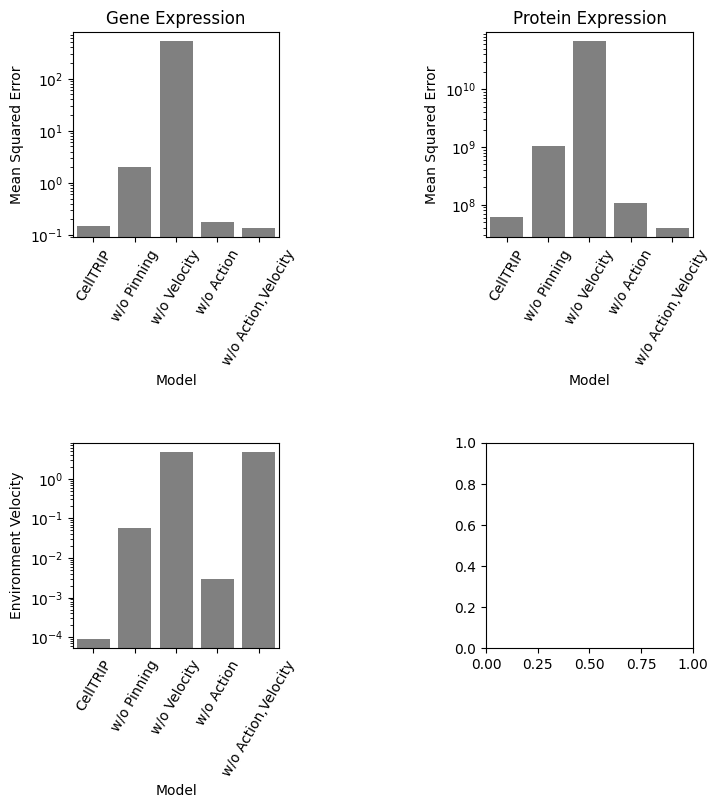

In [6]:
# Create figure
fig, axs = plt.subplots(2, 2, figsize=(8, 8))
fig.subplots_adjust(wspace=1., hspace=1.)

# Errors
for ax, modality in zip(axs[0], modalities):
    sns.barplot(
        errors.loc[errors['Modality']==modality],
        x='Model', y='Mean Squared Error', color='gray',
        ax=ax)
    ax.set(title=modality)
    ax.set_yscale('log')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=60)

# Statistics
ax = axs[1, 0]
sns.barplot(
    statistics, x='Model', y='Environment Velocity', color='gray', ax=ax)
ax.set_yscale('log')
ax.set_xticklabels(ax.get_xticklabels(), rotation=60)

# Save figure
fig.savefig('../plots/dyngen/Ablation.pdf')
